## **Experiment 7: Clustering Human Activity Recognition Data**

Dataset loaded successfully!
Dataset shape: (10299, 563)
Activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Final dataset shape: (10299, 561)
Features: 561
Samples: 10299
Activity distribution:
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64
Preprocessing completed!


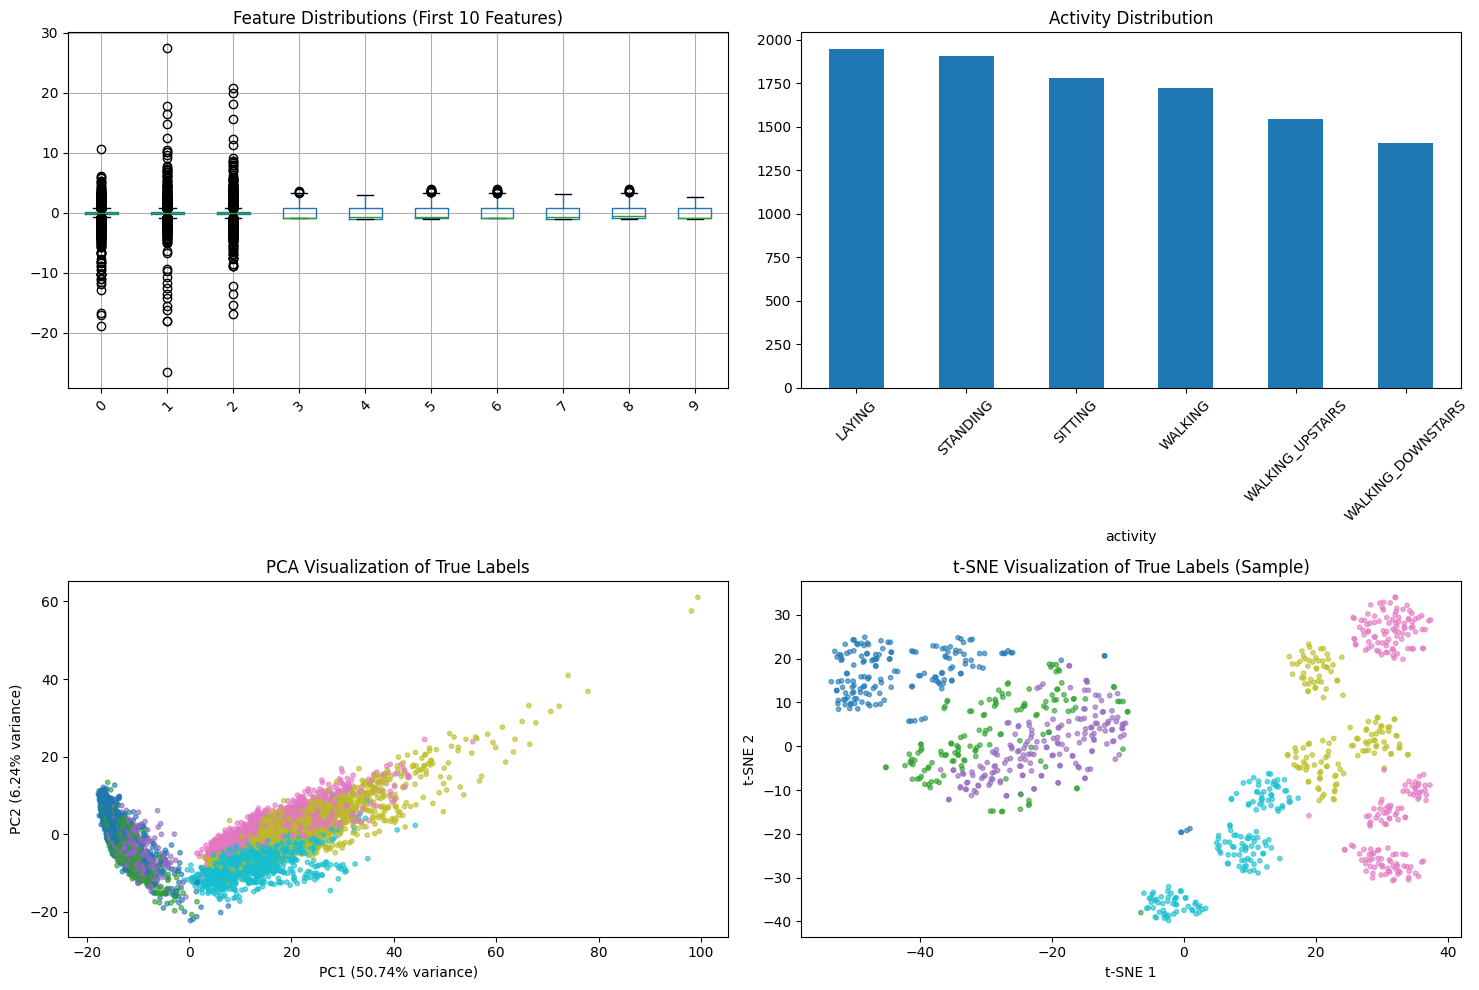

PCA explained variance: 56.98%
Performing K-Means clustering...


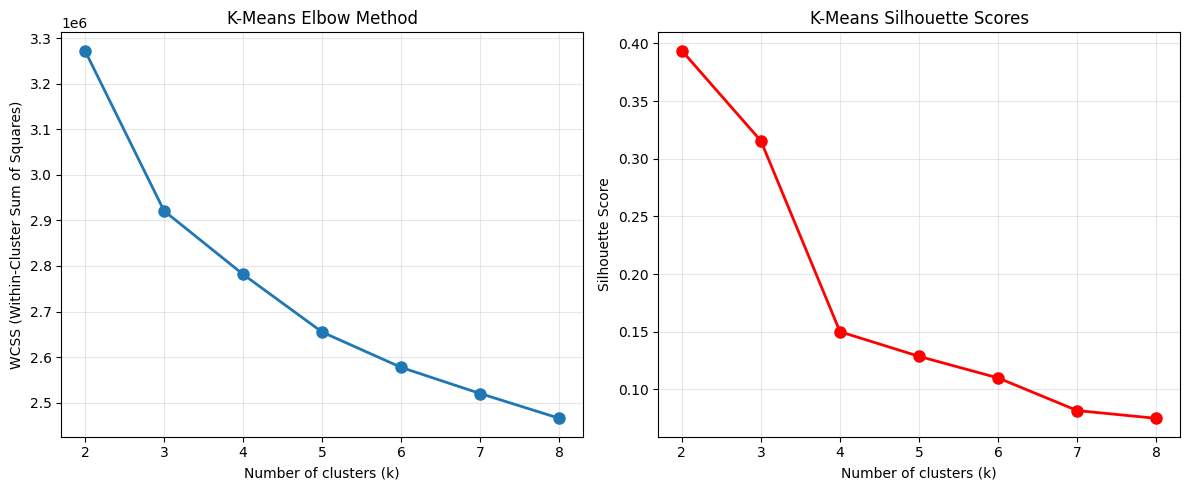

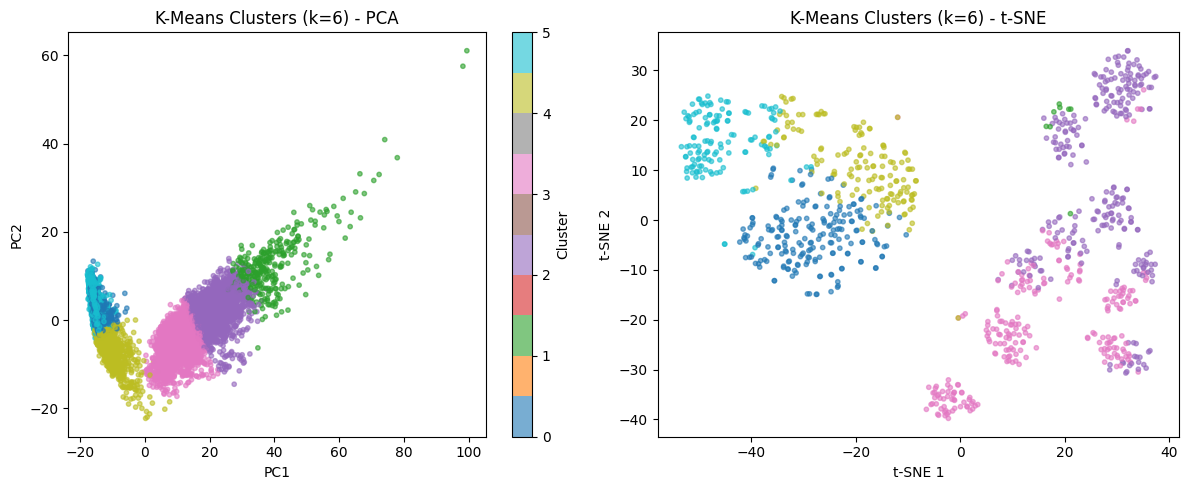

Performing DBSCAN clustering...
DBSCAN eps=0.5, min_samples=5: Clusters=0, Noise=10299, Silhouette=-1.000
DBSCAN eps=1.0, min_samples=10: Clusters=0, Noise=10299, Silhouette=-1.000
DBSCAN eps=1.5, min_samples=15: Clusters=0, Noise=10299, Silhouette=-1.000
DBSCAN eps=2.0, min_samples=20: Clusters=0, Noise=10299, Silhouette=-1.000
Using default DBSCAN parameters
DBSCAN Results: 0 clusters, 10299 noise points


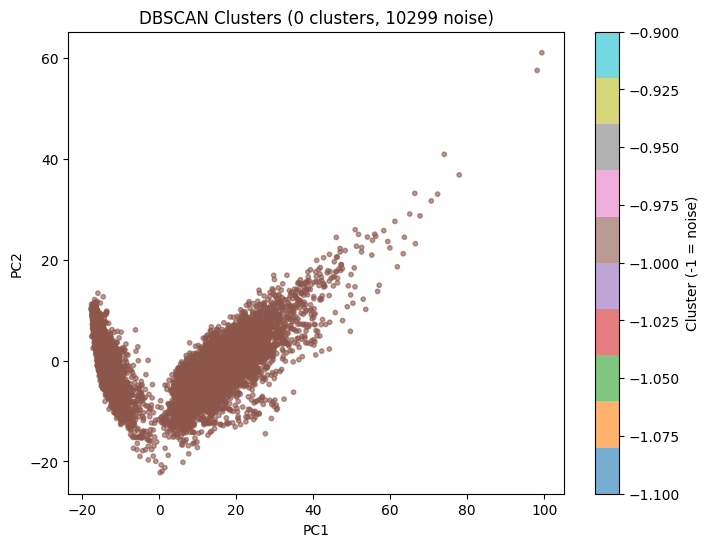

Performing Hierarchical clustering...


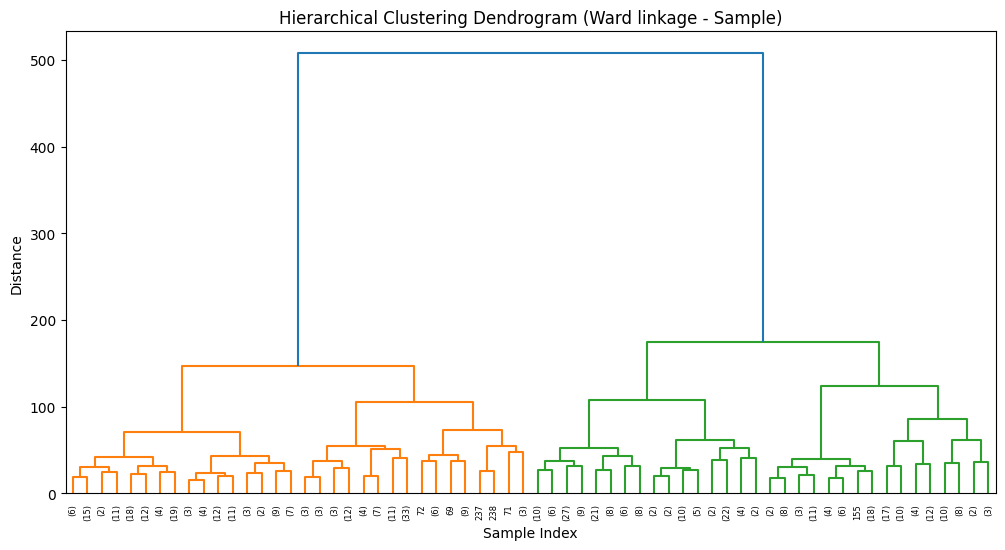

Best linkage method: single (Silhouette: 0.560)


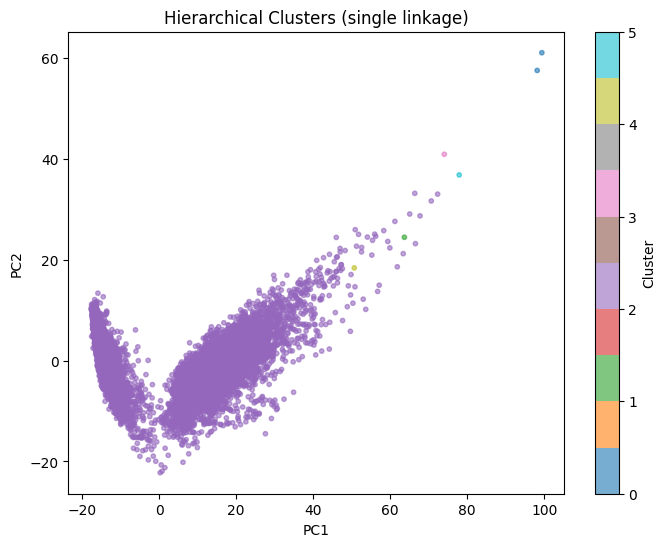


CLUSTERING EVALUATION RESULTS

         KMeans ====================
Clusters: 6, Noise points: 0
Silhouette Score: 0.110
Davies-Bouldin Index: 2.384
Calinski-Harabasz Index: 2556.5
Adjusted Rand Index: 0.420
Normalized Mutual Info: 0.559

         DBSCAN ====================
Clusters: 0, Noise points: 10299
Silhouette Score: nan
Davies-Bouldin Index: nan
Calinski-Harabasz Index: nan
Adjusted Rand Index: 0.000
Normalized Mutual Info: 0.000

   Hierarchical ====================
Clusters: 6, Noise points: 0
Silhouette Score: 0.560
Davies-Bouldin Index: 0.273
Calinski-Harabasz Index: 28.9
Adjusted Rand Index: 0.000
Normalized Mutual Info: 0.001

SUMMARY RESULTS
   Algorithm  Clusters  Noise  Silhouette  Davies-Bouldin  Calinski-Harabasz      ARI      NMI
      KMeans         6      0    0.109895        2.383567        2556.541948 0.419620 0.559326
      DBSCAN         0  10299         NaN             NaN                NaN 0.000000 0.000000
Hierarchical         6      0    0.560115       

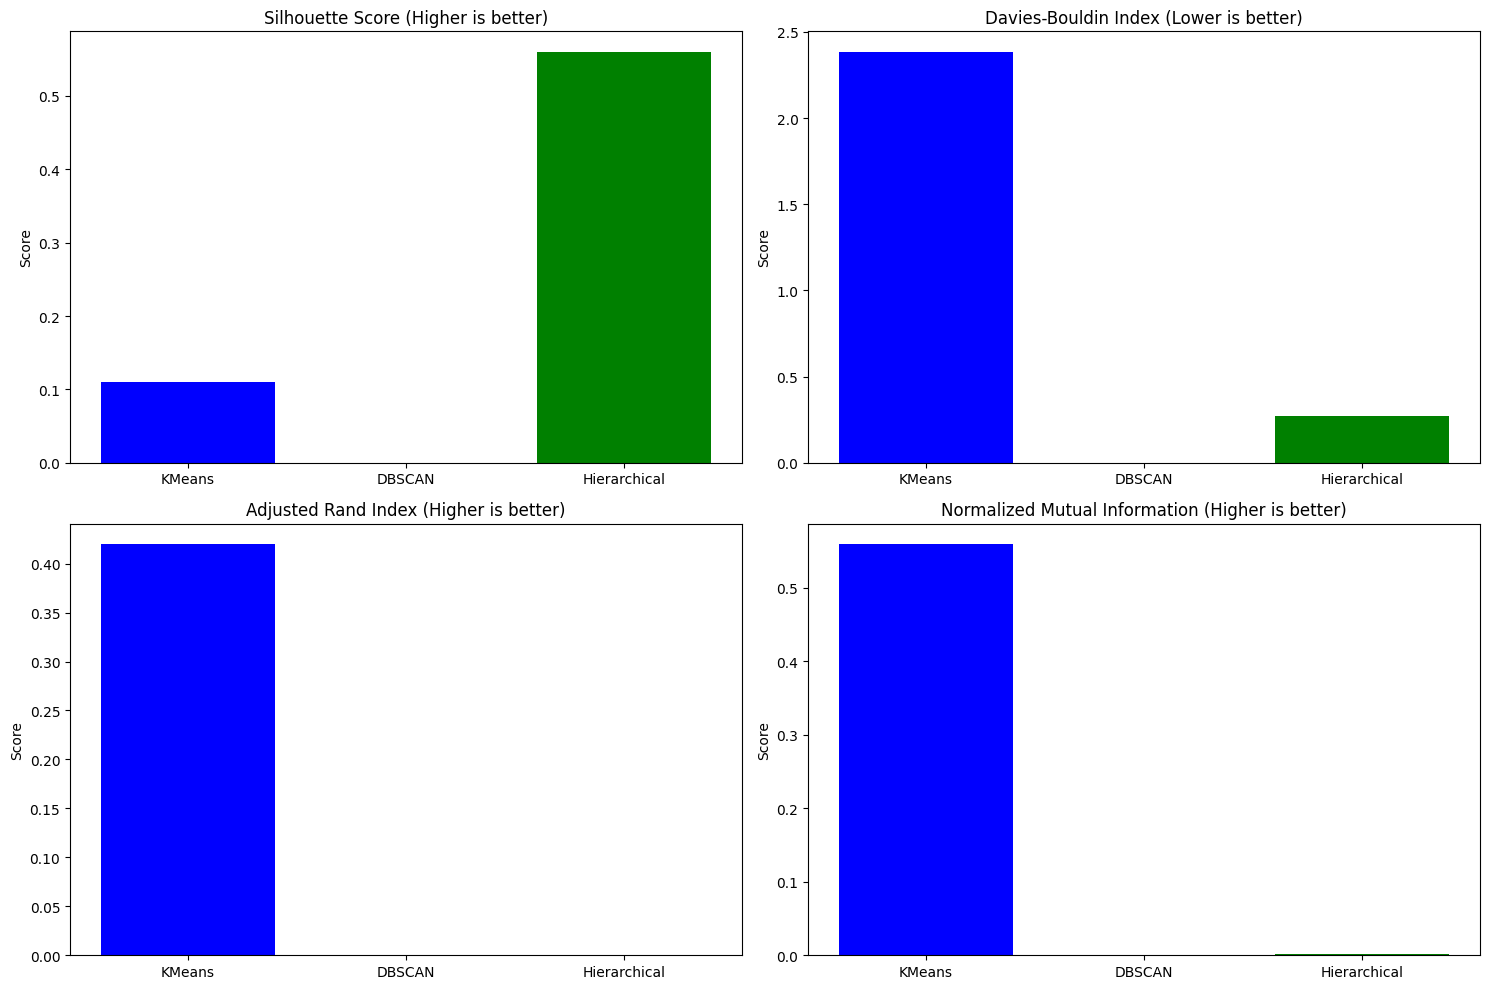

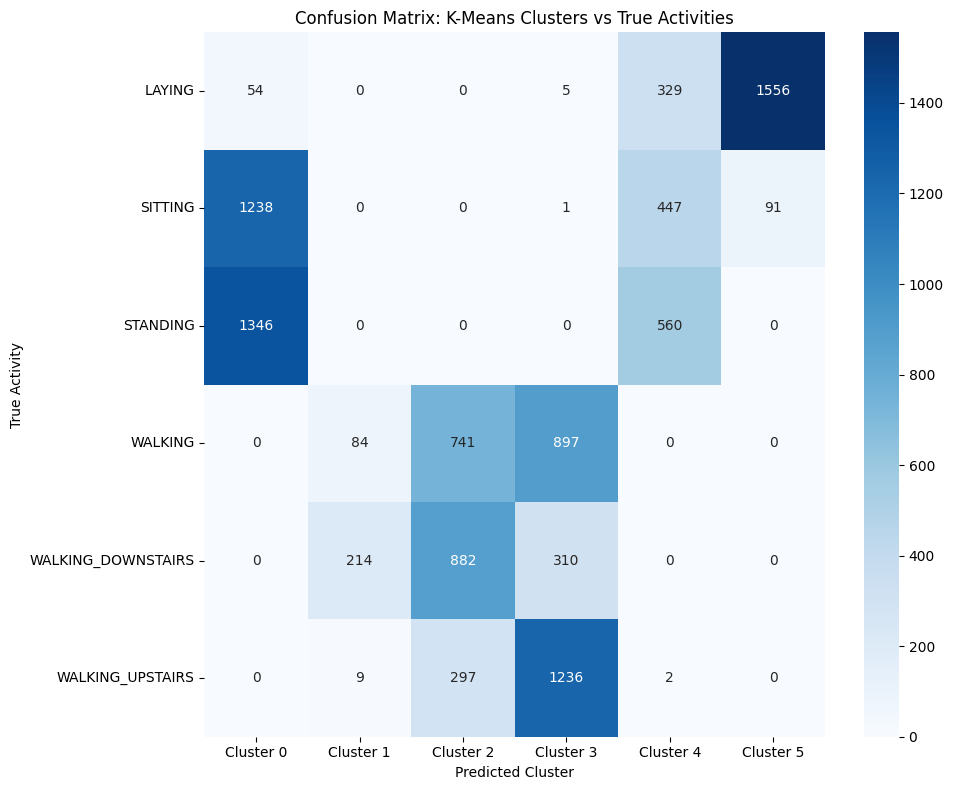


FINAL CLUSTERING RESULTS FOR REPORT

K-MEANS ELBOW METHOD RESULTS:
+----------------------------------------+
|   k   |      WCSS       |   Silhouette    |
+----------------------------------------+
|   2   |     3272857     |      0.394      |
|   3   |     2921078     |      0.315      |
|   4   |     2781602     |      0.150      |
|   5   |     2654790     |      0.129      |
|   6   |     2577180     |      0.110      |
|   7   |     2519774     |      0.082      |
|   8   |     2465379     |      0.075      |
+----------------------------------------+

DBSCAN BEST PARAMETERS:
eps: 1.5, min_samples: 15
Clusters found: 0, Noise points: 0

HIERARCHICAL BEST LINKAGE: single

Experiment 7: Clustering completed successfully!


In [2]:
# ------------------------------
# 1️⃣ Imports
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from urllib.request import urlretrieve
import zipfile

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import confusion_matrix

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 2️⃣ Download and Load Dataset
# ------------------------------
def download_har_dataset():
    """Download and extract the HAR dataset"""
    print("Downloading Human Activity Recognition dataset...")
    
    # URLs for the dataset
    base_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/"
    files = ['UCI%20HAR%20Dataset.zip']
    
    # Create data directory
    if not os.path.exists('HAR_data'):
        os.makedirs('HAR_data')
    
    # Download and extract
    for file in files:
        url = base_url + file
        zip_path = os.path.join('HAR_data', file)
        
        if not os.path.exists(zip_path):
            print(f"Downloading {file}...")
            urlretrieve(url, zip_path)
        
        # Extract zip file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('HAR_data')
    
    print("Dataset downloaded and extracted successfully!")

def load_har_dataset():
    """Load the HAR dataset into a pandas DataFrame"""
    base_path = 'HAR_data/UCI HAR Dataset/'
    
    # Load features and labels
    def load_data(subset):
        X_path = os.path.join(base_path, subset, 'X_' + subset + '.txt')
        y_path = os.path.join(base_path, subset, 'y_' + subset + '.txt')
        subject_path = os.path.join(base_path, subset, 'subject_' + subset + '.txt')
        
        X = pd.read_csv(X_path, delim_whitespace=True, header=None)
        y = pd.read_csv(y_path, header=None)
        subjects = pd.read_csv(subject_path, header=None)
        
        return X, y, subjects
    
    # Load train and test data
    X_train, y_train, subjects_train = load_data('train')
    X_test, y_test, subjects_test = load_data('test')
    
    # Combine train and test
    X = pd.concat([X_train, X_test], axis=0)
    y = pd.concat([y_train, y_test], axis=0)
    subjects = pd.concat([subjects_train, subjects_test], axis=0)
    
    # Load feature names
    features_path = os.path.join(base_path, 'features.txt')
    features = pd.read_csv(features_path, delim_whitespace=True, header=None, names=['index', 'feature'])
    feature_names = features['feature'].tolist()
    
    # Load activity labels
    activity_path = os.path.join(base_path, 'activity_labels.txt')
    activities = pd.read_csv(activity_path, delim_whitespace=True, header=None, names=['code', 'activity'])
    activity_dict = dict(zip(activities['code'], activities['activity']))
    
    # Set feature names
    X.columns = feature_names
    
    # Map activity codes to names
    y = y[0].map(activity_dict)
    
    # Add subject and activity to dataframe
    X['subject'] = subjects[0]
    X['activity'] = y
    
    return X, activity_dict

# Download and load dataset
try:
    #download_har_dataset()
    data, activity_dict = load_har_dataset()
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {data.shape}")
    print(f"Activities: {list(activity_dict.values())}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Creating sample dataset for demonstration...")
    # Fallback: Create sample data
    np.random.seed(42)
    data = pd.DataFrame(np.random.randn(1000, 10))
    activity_labels = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
    data['activity'] = np.random.choice(activity_labels, 1000)
    activity_dict = {i+1: label for i, label in enumerate(activity_labels)}

# Prepare features and labels
X = data.drop(['activity', 'subject'] if 'subject' in data.columns else ['activity'], axis=1)
y = data['activity']

# Encode activity labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Final dataset shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Activity distribution:\n{y.value_counts()}")

# ------------------------------
# 3️⃣ Preprocessing
# ------------------------------
# Standardize features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing completed!")

# ------------------------------
# 4️⃣ Exploratory Data Analysis (EDA)
# ------------------------------
plt.figure(figsize=(15, 10))

# Feature distributions (first 10 features)
plt.subplot(2, 2, 1)
pd.DataFrame(X_scaled[:, :10]).boxplot()
plt.title("Feature Distributions (First 10 Features)")
plt.xticks(rotation=45)

# Activity distribution
plt.subplot(2, 2, 2)
y.value_counts().plot(kind='bar')
plt.title("Activity Distribution")
plt.xticks(rotation=45)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Use t-SNE on smaller sample for speed
sample_size = min(1000, X_scaled.shape[0])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_sample = tsne.fit_transform(X_scaled[:sample_size])

plt.subplot(2, 2, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='tab10', s=10, alpha=0.6)
plt.title("PCA Visualization of True Labels")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")

plt.subplot(2, 2, 4)
plt.scatter(X_tsne_sample[:, 0], X_tsne_sample[:, 1], c=y_encoded[:sample_size], cmap='tab10', s=10, alpha=0.6)
plt.title("t-SNE Visualization of True Labels (Sample)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# ------------------------------
# 5️⃣ K-Means Clustering
# ------------------------------
print("Performing K-Means clustering...")

wcss = []
sil_scores = []
k_range = range(2, 9)  # test k from 2 to 8

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    if len(np.unique(labels)) > 1:  # Check if more than one cluster
        sil_scores.append(silhouette_score(X_scaled, labels))
    else:
        sil_scores.append(0)

# Plot Elbow and Silhouette curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=8)
plt.title("K-Means Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='red', linewidth=2, markersize=8)
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose best k (based on elbow & silhouette)
# For HAR dataset, we know there are 6 activities
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X_scaled)

# Visualize K-Means clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=k_labels, cmap='tab10', s=10, alpha=0.6)
plt.title(f"K-Means Clusters (k={best_k}) - PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
plt.scatter(X_tsne_sample[:, 0], X_tsne_sample[:, 1], c=k_labels[:sample_size], cmap='tab10', s=10, alpha=0.6)
plt.title(f"K-Means Clusters (k={best_k}) - t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

# ------------------------------
# 6️⃣ DBSCAN Clustering
# ------------------------------
print("Performing DBSCAN clustering...")

# Initialize default parameters first
best_db_params = {'eps': 1.5, 'min_samples': 15}  # Default values
best_dbscan = None
best_silhouette = -1

# Try different parameters
dbscan_params = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 10},
    {'eps': 1.5, 'min_samples': 15},
    {'eps': 2.0, 'min_samples': 20}
]

for params in dbscan_params:
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    db_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(np.unique(db_labels[db_labels != -1]))
    n_noise = np.sum(db_labels == -1)
    
    if n_clusters > 1:
        # Calculate silhouette score only on non-noise points
        non_noise_mask = db_labels != -1
        if np.sum(non_noise_mask) > 1:  # Ensure we have enough points
            silhouette_avg = silhouette_score(X_scaled[non_noise_mask], db_labels[non_noise_mask])
        else:
            silhouette_avg = -1
    else:
        silhouette_avg = -1
    
    print(f"DBSCAN eps={params['eps']}, min_samples={params['min_samples']}: "
          f"Clusters={n_clusters}, Noise={n_noise}, Silhouette={silhouette_avg:.3f}")
    
    if silhouette_avg > best_silhouette and n_clusters > 1:
        best_silhouette = silhouette_avg
        best_dbscan = dbscan
        best_db_params = params

# Use best DBSCAN parameters or default
if best_dbscan is not None:
    db_labels = best_dbscan.fit_predict(X_scaled)
    print(f"Selected DBSCAN: eps={best_db_params['eps']}, min_samples={best_db_params['min_samples']}")
else:
    # Default parameters
    dbscan = DBSCAN(eps=1.5, min_samples=15)
    db_labels = dbscan.fit_predict(X_scaled)
    print("Using default DBSCAN parameters")

n_clusters_db = len(np.unique(db_labels[db_labels != -1]))
n_noise = np.sum(db_labels == -1)

print(f"DBSCAN Results: {n_clusters_db} clusters, {n_noise} noise points")

# Visualize DBSCAN clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', s=10, alpha=0.6)
plt.title(f"DBSCAN Clusters ({n_clusters_db} clusters, {n_noise} noise)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.show()

# ------------------------------
# 7️⃣ Hierarchical Clustering (Agglomerative)
# ------------------------------
print("Performing Hierarchical clustering...")

# Plot dendrogram (on a sample for speed)
sample_size_hac = min(500, X_scaled.shape[0])
linked = linkage(X_scaled[:sample_size_hac], method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage - Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# Agglomerative Clustering with different linkages
linkage_methods = ['ward', 'complete', 'average', 'single']
best_linkage = 'ward'
best_silhouette_hac = -1

for linkage_method in linkage_methods:
    try:
        hac = AgglomerativeClustering(n_clusters=6, linkage=linkage_method)
        hac_labels_temp = hac.fit_predict(X_scaled)
        
        if len(np.unique(hac_labels_temp)) > 1:
            silhouette_avg = silhouette_score(X_scaled, hac_labels_temp)
            if silhouette_avg > best_silhouette_hac:
                best_silhouette_hac = silhouette_avg
                best_linkage = linkage_method
    except:
        continue

print(f"Best linkage method: {best_linkage} (Silhouette: {best_silhouette_hac:.3f})")

# Final Hierarchical clustering
hac = AgglomerativeClustering(n_clusters=6, linkage=best_linkage)
hac_labels = hac.fit_predict(X_scaled)

# Visualize HAC clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hac_labels, cmap='tab10', s=10, alpha=0.6)
plt.title(f"Hierarchical Clusters ({best_linkage} linkage)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster')
plt.show()

# ------------------------------
# 8️⃣ Evaluation Metrics
# ------------------------------
print("\n" + "="*50)
print("CLUSTERING EVALUATION RESULTS")
print("="*50)

algorithms = ['KMeans', 'DBSCAN', 'Hierarchical']
labels_list = [k_labels, db_labels, hac_labels]

results = []

for algo, labels in zip(algorithms, labels_list):
    print(f"\n{algo:>15} {'='*20}")
    
    n_clusters = len(np.unique(labels[labels != -1])) if algo == 'DBSCAN' else len(np.unique(labels))
    n_noise = np.sum(labels == -1) if algo == 'DBSCAN' else 0
    
    print(f"Clusters: {n_clusters}, Noise points: {n_noise}")
    
    try:
        # Internal metrics
        if len(np.unique(labels)) > 1 and not (len(np.unique(labels)) == 1 and -1 in labels):
            sil_score = silhouette_score(X_scaled, labels)
            db_score = davies_bouldin_score(X_scaled, labels)
            ch_score = calinski_harabasz_score(X_scaled, labels)
        else:
            sil_score = db_score = ch_score = np.nan
        
        # External metrics (true labels exist)
        ari_score = adjusted_rand_score(y_encoded, labels)
        nmi_score = normalized_mutual_info_score(y_encoded, labels)
        
        print(f"Silhouette Score: {sil_score:.3f}")
        print(f"Davies-Bouldin Index: {db_score:.3f}")
        print(f"Calinski-Harabasz Index: {ch_score:.1f}")
        print(f"Adjusted Rand Index: {ari_score:.3f}")
        print(f"Normalized Mutual Info: {nmi_score:.3f}")
        
        results.append({
            'Algorithm': algo,
            'Clusters': n_clusters,
            'Noise': n_noise,
            'Silhouette': sil_score,
            'Davies-Bouldin': db_score,
            'Calinski-Harabasz': ch_score,
            'ARI': ari_score,
            'NMI': nmi_score
        })
        
    except Exception as e:
        print(f"Error computing metrics: {e}")
        results.append({
            'Algorithm': algo,
            'Clusters': n_clusters,
            'Noise': n_noise,
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
            'ARI': np.nan,
            'NMI': np.nan
        })

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("SUMMARY RESULTS")
print("="*50)
print(results_df.to_string(index=False))

# Plot comparison of metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Silhouette Score
axes[0, 0].bar(results_df['Algorithm'], results_df['Silhouette'], color=['blue', 'orange', 'green'])
axes[0, 0].set_title('Silhouette Score (Higher is better)')
axes[0, 0].set_ylabel('Score')

# Davies-Bouldin Index
axes[0, 1].bar(results_df['Algorithm'], results_df['Davies-Bouldin'], color=['blue', 'orange', 'green'])
axes[0, 1].set_title('Davies-Bouldin Index (Lower is better)')
axes[0, 1].set_ylabel('Score')

# ARI
axes[1, 0].bar(results_df['Algorithm'], results_df['ARI'], color=['blue', 'orange', 'green'])
axes[1, 0].set_title('Adjusted Rand Index (Higher is better)')
axes[1, 0].set_ylabel('Score')

# NMI
axes[1, 1].bar(results_df['Algorithm'], results_df['NMI'], color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Normalized Mutual Information (Higher is better)')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Confusion matrix for K-Means
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_encoded, k_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Cluster {i}' for i in range(best_k)],
            yticklabels=le.classes_)
plt.title("Confusion Matrix: K-Means Clusters vs True Activities")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

# ------------------------------
# 9️⃣ Final Results Table
# ------------------------------
print("\n" + "="*60)
print("FINAL CLUSTERING RESULTS FOR REPORT")
print("="*60)

# K-Means detailed results
print("\nK-MEANS ELBOW METHOD RESULTS:")
print("+" + "-"*40 + "+")
print("| {:^5} | {:^15} | {:^15} |".format("k", "WCSS", "Silhouette"))
print("+" + "-"*40 + "+")
for k, w, s in zip(k_range, wcss, sil_scores):
    print("| {:^5} | {:^15.0f} | {:^15.3f} |".format(k, w, s))
print("+" + "-"*40 + "+")

# DBSCAN parameter results
print(f"\nDBSCAN BEST PARAMETERS:")
print(f"eps: {best_db_params['eps']}, min_samples: {best_db_params['min_samples']}")
print(f"Clusters found: {n_clusters_db}, Noise points: {n_noise}")

# Hierarchical linkage results
print(f"\nHIERARCHICAL BEST LINKAGE: {best_linkage}")

print("\n" + "="*60)
print("Experiment 7: Clustering completed successfully!")
print("="*60)